In [1]:
import torch
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mint.helpers.extract import load_config, MINTWrapper, CSVDataset, CollateFn
from torch.utils.data import DataLoader

RuntimeError: CPU dispatcher tracer already initlized

In [2]:
# Setup device and paths
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
mint_config_path = "../mint/data/esm2_t33_650M_UR50D.json"     # Point to your esm2 650M config
mint_weights_path = "../model_checkpoints/mint_base/mint.ckpt" # Point to downloaded MINT weights

In [3]:
# Load the embedding extractor
cfg = load_config(mint_config_path)
wrapper = MINTWrapper(cfg, mint_weights_path, sep_chains=False, device=device)
wrapper.eval() # Set to evaluation mode
print(f"MINT Base Model Loaded Successfully on {device}.")

MINT Base Model Loaded Successfully on cuda:0.


In [4]:
hmas = {
    "Pikm-1": "GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVVVGDGIDSINLVSALRKKVGPAMFLEVSQVKED",
    "Pikp-1": "GLKQKIVIKVAMEGNNCRSKAMALVASTGGVDSVALVGDLRDKIEVVGYGIDPIKLISALRKKVGDAELLQVSQANKD",
    "OsHIPP20": "MTKQKIVIKVSMPCEKSRSKAMALVARASGVNSMEVTGDGKDRLQVVGDGVDPVCLVACLRRKIGYAEIVQVEEVKDK"
}

avrs = {
    "AVR-PikA (WT)": "ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDAGTCYSSWKMDMKVGPNWVHIKSDDNCNLSGDFPPGWIVLGKKRPGF",
    "AVR-PikF": "ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDAGTCYSSWKMDKKVGPNWVHIKSDDNCNLSGDFPPGWIVLGKKRPGF",
    "AVR-PikC": "ETGNKYIEKRAIDLSRERDPNFFDNPGIPVPECFWFMFKNNVRQDDGTCYSSWKMDMKVGPNWVHIKSDDNCNLSGDFPPGWIVLGKKRPGF",
    "AVR-PikD": "ETGNKYIEKRAIDLSRERDPNFFDHPGIPVPECFWFMFKNNVRQDAGTCYSSWKMDMKVGPNWVHIKSDDNCNLSGDFPPGWIVLGKKRPGF",
    "AVR-PikE": "ETGNKYIEKRAIDLSRERDPNFFDNPGIPVPECFWFMFKNNVRQDAGTCYSSWKMDMKVGPNWVHIKSDDNCNLSGDFPPGWIVLGKKRPGF",
    "AVR-PikI": "ETGNKYIEKRAIDLSRERDPNFFDNPGIPVPECFWFMFKNNVRQDAGTCYSSWKMDMKVGPNWVHIKSDDNCNLSGDFPPGWIVLGKKGPAF",
    "AVR-PikK": "ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFIFKNNVRQDAGTCYSSWKMDKKVGPNWVHIKSDDNCNLSGDFPPGWIVLGKKRPGF"
}

# Build Combinations List (Using AVR-PikA as the WT reference for all)
records = []
for hma_name, hma_seq in hmas.items():
    for avr_name, avr_seq in avrs.items():
        records.append({
            "HMA_Domain": hma_name,
            "AVR_Allele": avr_name,
            "seq1_wt": hma_seq, 
            "seq2_wt": avrs["AVR-PikA (WT)"],
            "seq1_mut": hma_seq, 
            "seq2_mut": avr_seq
        })

df_combos = pd.DataFrame(records)
df_combos

,HMA_Domain,AVR_Allele,seq1_wt,seq2_wt,seq1_mut,seq2_mut
0,Pikm-1,AVR-PikA (WT),GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...
1,Pikm-1,AVR-PikF,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...
2,Pikm-1,AVR-PikC,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNPGIPVPECFWFMFKNNVRQDD...
3,Pikm-1,AVR-PikD,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDHPGIPVPECFWFMFKNNVRQDA...
4,Pikm-1,AVR-PikE,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNPGIPVPECFWFMFKNNVRQDA...
5,Pikm-1,AVR-PikI,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNPGIPVPECFWFMFKNNVRQDA...
6,Pikm-1,AVR-PikK,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GEMQKIVFKIPMVDDKSRTKAMSLVASTVGVHSVAIAGDLRDQVVV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFIFKNNVRQDA...
7,Pikp-1,AVR-PikA (WT),GLKQKIVIKVAMEGNNCRSKAMALVASTGGVDSVALVGDLRDKIEV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GLKQKIVIKVAMEGNNCRSKAMALVASTGGVDSVALVGDLRDKIEV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...
8,Pikp-1,AVR-PikF,GLKQKIVIKVAMEGNNCRSKAMALVASTGGVDSVALVGDLRDKIEV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GLKQKIVIKVAMEGNNCRSKAMALVASTGGVDSVALVGDLRDKIEV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...
9,Pikp-1,AVR-PikC,GLKQKIVIKVAMEGNNCRSKAMALVASTGGVDSVALVGDLRDKIEV...,ETGNKYIEKRAIDLSRERDPNFFDNADIPVPECFWFMFKNNVRQDA...,GLKQKIVIKVAMEGNNCRSKAMALVASTGGVDSVALVGDLRDKIEV...,ETGNKYIEKRAIDLSRERDPNFFDNPGIPVPECFWFMFKNNVRQDD...


In [5]:
# Create Temporary CSV for MINT DataLoader
# We stack all WT complexes followed by all Mutant complexes vertically
df_extract = pd.DataFrame({
    "seq1": df_combos["seq1_wt"].tolist() + df_combos["seq1_mut"].tolist(),
    "seq2": df_combos["seq2_wt"].tolist() + df_combos["seq2_mut"].tolist()
})
df_extract.to_csv("temp_combinations.csv", index=False)

In [6]:
# Extract Embeddings (Assuming 'wrapper' and 'device' are initialized from Cell 1)
dataset = CSVDataset("temp_combinations.csv", col1="seq1", col2="seq2")
# Batch size 4 will speed up processing; using CollateFn(1024) to handle tokenization
loader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=CollateFn(1024))

all_embs = []
with torch.no_grad():
    for chains, chain_ids in loader:
        chains = chains.to(device)
        chain_ids = chain_ids.to(device)
        embs = wrapper(chains, chain_ids)
        all_embs.append(embs.cpu())

all_embs = torch.cat(all_embs, dim=0)

In [7]:
# Calculate Delta Feature Vectors
n_pairs = len(df_combos)
wt_embs = all_embs[:n_pairs]   # First half are WT
mut_embs = all_embs[n_pairs:]  # Second half are Mutants

feature_vectors = (wt_embs - mut_embs).numpy()

# Predict ΔΔG
# Load model weights from SKEMPI fine-tuning
checkpoint_path = "/home/oscar/evolutionary_simulations/model_checkpoints/mint_mut_ppi/best_SKEMPI_mint_split_1_rep1.joblib"
predictor = joblib.load(checkpoint_path)

# Make predictions
predicted_ddG = predictor.predict(feature_vectors)
df_combos["Predicted_ddG"] = predicted_ddG

# Filter out the WT-vs-WT comparisons (which will always be exactly 0.0) for cleaner plotting
df_plot = df_combos[df_combos["AVR_Allele"] != "AVR-PikA (WT)"]

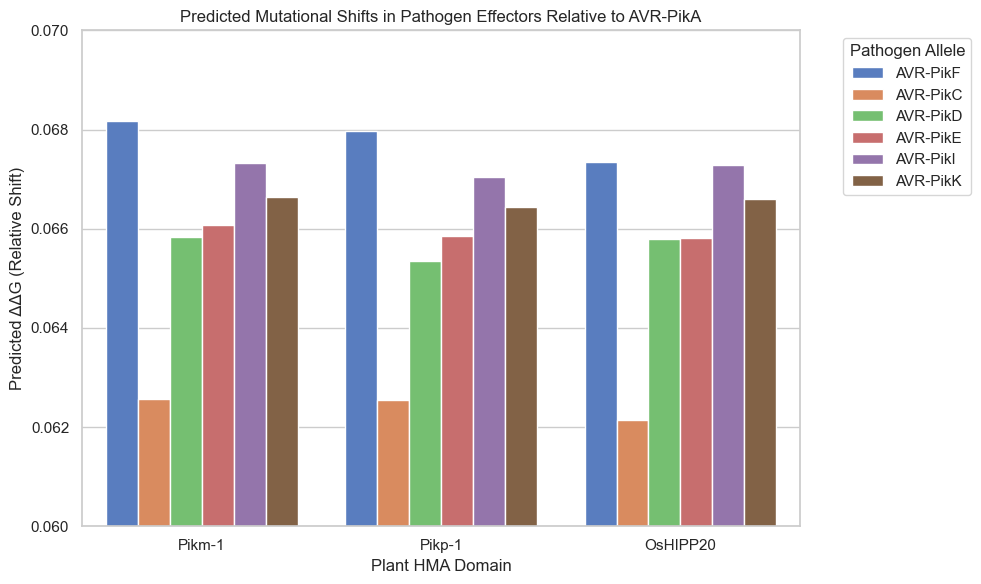

In [10]:
# Plotting the Results
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Grouped bar chart (Swapped X and Hue)
ax = sns.barplot(
    data=df_plot, 
    x="HMA_Domain", 
    y="Predicted_ddG", 
    hue="AVR_Allele", 
    palette="muted"
)

plt.title("Predicted Mutational Shifts in Pathogen Effectors Relative to AVR-PikA")
plt.xlabel("Plant HMA Domain")
plt.ylabel("Predicted ΔΔG (Relative Shift)")

# Zoom the Y-axis to the specific range of the micro-shifts
plt.ylim(0.06, 0.07)

# Move the legend completely outside the main plot area
plt.legend(title="Pathogen Allele", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to ensure the external legend isn't cut off
plt.tight_layout()
plt.show()

Pikp-1 and Pikm-1 show basically the same pattern. I can tell that there seems to be a correlation with the number of mutations between AVR-PikA and the allele tested. Let's test for that correlation.

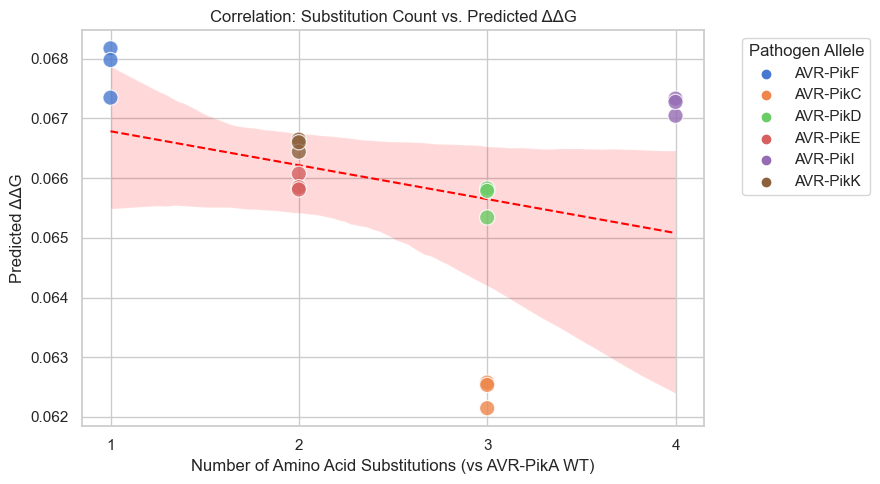

Pearson Correlation between Mutation Count and ΔΔG: -0.311


In [11]:
# Function to calculate the number of amino acid differences (Hamming distance)
def count_mutations(wt_seq, mut_seq):
    return sum(1 for a, b in zip(wt_seq, mut_seq) if a != b)

# Apply the count to your dataframe
df_plot = df_plot.copy() # Avoid SettingWithCopyWarning
df_plot["Num_Mutations"] = df_plot.apply(
    lambda row: count_mutations(row["seq2_wt"], row["seq2_mut"]), axis=1
)

# Plot Number of Mutations vs. Predicted ΔΔG
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# 1. Draw the scatter points colored by the AVR-Pik allele
sns.scatterplot(
    data=df_plot,
    x="Num_Mutations",
    y="Predicted_ddG",
    hue="AVR_Allele",
    s=120,
    alpha=0.8,
    palette="muted",
    zorder=3 # Ensures points sit cleanly on top of the grid lines
)

# 2. Layer the global regression trendline on top (disabling its default scatter points)
sns.regplot(
    data=df_plot, 
    x="Num_Mutations", 
    y="Predicted_ddG", 
    scatter=False,
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 1.5}
)

plt.title("Correlation: Substitution Count vs. Predicted ΔΔG")
plt.xlabel("Number of Amino Acid Substitutions (vs AVR-PikA WT)")
plt.ylabel("Predicted ΔΔG")
plt.xticks(range(1, df_plot["Num_Mutations"].max() + 1))

# Move the legend outside so it doesn't crowd the trendline
plt.legend(title="Pathogen Allele", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print the exact correlation coefficient
correlation = df_plot["Num_Mutations"].corr(df_plot["Predicted_ddG"])
print(f"Pearson Correlation between Mutation Count and ΔΔG: {correlation:.3f}")

Yep, and it's interesting to see that, between C and D which both have 3 mutations, D is much lower. This suggests to me I will need to factor out the contribution to ddG due only to the number of mutations. 

To do this, I'll fit a linear model between the number of mutations and the predicted ddG. Then I can just subtract the contribution due to number of mutations.

UPDATE: Now that I've added AVR-PikI, it seems to break that pattern. Not nearly as strong a correlation.

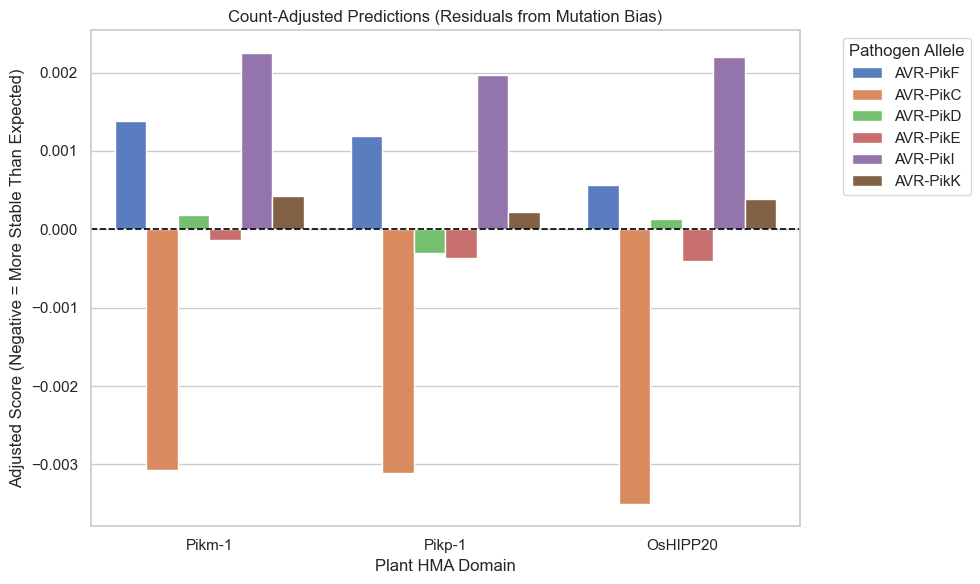

,HMA_Domain,AVR_Allele,Num_Mutations,Predicted_ddG,Adjusted_ddG
1,Pikm-1,AVR-PikF,1,0.068175,0.001389
2,Pikm-1,AVR-PikC,3,0.062576,-0.003073
3,Pikm-1,AVR-PikD,3,0.065826,0.000178
4,Pikm-1,AVR-PikE,2,0.066075,-0.000142
5,Pikm-1,AVR-PikI,4,0.067332,0.002251
6,Pikm-1,AVR-PikK,2,0.066647,0.000429
8,Pikp-1,AVR-PikF,1,0.067979,0.001194
9,Pikp-1,AVR-PikC,3,0.062536,-0.003112
10,Pikp-1,AVR-PikD,3,0.065342,-0.000307
11,Pikp-1,AVR-PikE,2,0.065848,-0.000369


In [12]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_plot.copy()

# Fit the linear regression to map the exact bias
slope, intercept, r_value, p_value, std_err = linregress(df_plot['Num_Mutations'], df_plot['Predicted_ddG'])

# Calculate what the model "lazily" expects based ONLY on mutation count
df_plot['Expected_Bias_ddG'] = intercept + (slope * df_plot['Num_Mutations'])

# Calculate the Residual (The "Adjusted" ddG)
# Residual = Actual Prediction - Expected Bias
df_plot['Adjusted_ddG'] = df_plot['Predicted_ddG'] - df_plot['Expected_Bias_ddG']

# Plot the newly adjusted scores
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# We use the Adjusted_ddG instead of the raw prediction
ax = sns.barplot(
    data=df_plot, 
    x="HMA_Domain", 
    y="Adjusted_ddG", 
    hue="AVR_Allele", 
    palette="muted"
)

plt.title("Count-Adjusted Predictions (Residuals from Mutation Bias)")
plt.xlabel("Plant HMA Domain")
plt.ylabel("Adjusted Score (Negative = More Stable Than Expected)")

# A line at 0 now represents the "average" stability for a given mutation count
plt.axhline(0, color='black', linewidth=1.2, linestyle='--') 

plt.legend(title="Pathogen Allele", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(df_plot[["HMA_Domain", "AVR_Allele", "Num_Mutations", "Predicted_ddG", "Adjusted_ddG"]])

With the final set of validated datapoints, I can say that, unfortunately, this model doesn't work well at all to predict binding affinities of AVR-Pik-HMA interactions. But, I suppose that's support that we need a more specialized model.

Never the less, this is more or less the prediction scheme I'll need, and a model of comparable size. So, I'll give myself the greenlight to start building the simulation framework around this prediction engine.